# MAGI — Example UsageA runnable, fully-commented walkthrough of the whole MAGI pipeline — load → preprocess →build dataset → train → generate → validate → export — using a **small syntheticdataset**, not real training data. This exists to show *how the API fits together*, notto produce a good model: a few hundred fabricated rows and 3 training epochs run in wellunder a minute, versus real runs which use hundreds of millions of events and tens oftraining epochs (see the `MAGI_v0_*.ipynb` notebooks at the repo root for those).See [`MAGI_package/docs/USAGE.md`](MAGI_package/docs/USAGE.md) for the full usage guide,including current limitations (sphere-only geometry, the `geometry_transform` contract,particle-type filtering, energy-binning tradeoffs, and the `source_type` flux-normalization choice) that this notebook only touches briefly.

In [1]:
import numpy as np
import pandas as pd
import magi

magi.initialize_environment(seed=42, cpu_only=True, quiet=True)

## 1. The input schemaMAGI reads Geant4 crossing-data files with `magi.data.load_detector_table`. Three columnschemas are auto-detected from the field count on the first data line:- **9 columns** (legacy): `EventId ParticleName Energy X Y Z Vx Vy Vz`- **10 columns**: adds `PrimBool` (1 = primary, i.e. the GPS-thrown particle reached the  surface unmodified; 0 = secondary)- **13 columns** ("lineage"): additionally carries `ParticleId`, `ParentParticleId`,  `CreatorProcessName` — needed for radioactive-decay sources, where `PrimBool` is  *always* 0 (the literal primary track is the decaying nucleus, which never propagates  anywhere) so "primary" has to be redefined as  `CreatorProcessName == "RadioactiveDecay"` instead. See `source_type` in step 3 below.Below we fabricate a small 10-column (`PrimBool`) dataset mimicking a cosmic-ray-stylesource — particles crossing a sphere of radius `R` centered at `center` — write it to afile, then load it back exactly as you would a real Geant4 output file.

In [2]:
rng = np.random.default_rng(42)
N = 4000
center = (0.0, 0.0, -50.0)  # mm
R = 20.0                     # mm

particle_names = rng.choice(["gamma", "e-", "mu-"], size=N, p=[0.6, 0.3, 0.1])
energy = np.where(
    particle_names == "gamma",
    rng.lognormal(mean=-1.0, sigma=0.6, size=N),
    rng.lognormal(mean=0.2, sigma=0.8, size=N),
)

# Positions uniformly distributed on the sphere surface
phi = rng.uniform(-np.pi, np.pi, N)
costheta = rng.uniform(-1, 1, N)
sintheta = np.sqrt(1 - costheta**2)
x = center[0] + R * sintheta * np.cos(phi)
y = center[1] + R * sintheta * np.sin(phi)
z = center[2] + R * costheta

# Isotropic unit directions
vphi = rng.uniform(-np.pi, np.pi, N)
vcostheta = rng.uniform(-1, 1, N)
vsintheta = np.sqrt(1 - vcostheta**2)
vx = vsintheta * np.cos(vphi)
vy = vsintheta * np.sin(vphi)
vz = vcostheta

prim_bool = rng.integers(0, 2, N)

df_raw = pd.DataFrame({
    "EventId": np.arange(N),
    "ParticleName": particle_names,
    "Energy": energy,
    "PrimBool": prim_bool,
    "X": x, "Y": y, "Z": z,
    "Vx": vx, "Vy": vy, "Vz": vz,
})

example_input_path = "example_crossing_data.dat"
df_raw.to_csv(example_input_path, sep="\t", header=False, index=False)

# Load it back exactly as you would a real Geant4 crossing-data file
df = magi.load_detector_table(example_input_path, sep=r"\s+")
print("Loaded columns:", df.columns.tolist())
magi.report_basic_table_checks(df)

Loaded columns: ['ParticleName', 'Energy', 'PrimBool', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']
N rows: 4000
  ParticleName    Energy  PrimBool          X          Y          Z        Vx  \
0           e-  0.495222         1  10.133398  14.720525 -58.978885  0.451772   
1        gamma  0.149869         1  -5.926216  -6.837944 -67.835989  0.342440   
2           e-  1.966607         1  -3.575008  -2.133520 -30.438113  0.504417   
3           e-  0.990583         1  12.242936 -11.128759 -38.763397  0.522769   
4        gamma  0.276526         0  -0.122724 -19.984740 -50.771435  0.968465   

         Vy        Vz  
0 -0.712774  0.536522  
1  0.775521 -0.530379  
2  0.804619 -0.313292  
3  0.299894  0.797983  
4  0.174853 -0.177489  

NaN per column:
 ParticleName    0
Energy          0
PrimBool        0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64

PrimBool present: n_primaries=1981 n_generated=4000 primary_fraction=0.495

### Aside: the radioactive-source schemaNot run through the main pipeline below, just shown for reference. A source embedded inbulk material (e.g. K-40 in concrete) needs the 13-column lineage schema, and`source_type="radioactive"` when building physical features (step 3) — using`source_type="cosmic_ray"` (the default) on this kind of data would silently report`primary_fraction ≈ 0`, since `PrimBool` is never 1 for a decay source.

In [3]:
creators = rng.choice(["RadioactiveDecay"] * 9 + ["eBrem"], 200)  # ~90% decay, ~10% EM secondaries
radio_lines = []
for i in range(200):
    E = rng.uniform(0.1, 2.0)
    track_id = rng.integers(2, 20)
    parent_id = rng.integers(2, 15)
    rx, ry, rz = rng.normal(0, 5, 3)
    rv = rng.normal(size=3)
    rv /= np.linalg.norm(rv)
    radio_lines.append(
        f"{i}\tgamma\t{E}\t0\t{track_id}\t{parent_id}\t{creators[i]}\t"
        f"{rx}\t{ry}\t{rz}\t{rv[0]}\t{rv[1]}\t{rv[2]}"
    )

radioactive_path = "example_radioactive_data.dat"
with open(radioactive_path, "w") as f:
    f.write("\n".join(radio_lines) + "\n")

df_radio = magi.load_detector_table(radioactive_path)
print("Lineage columns:", df_radio.columns.tolist())

prep_radio = magi.build_physical_features(
    df_radio, center=(0.0, 0.0, 0.0), radius=10.0, source_type="radioactive",
)
print("normalization:", prep_radio["normalization"])

Lineage columns: ['ParticleName', 'Energy', 'PrimBool', 'ParticleId', 'ParentParticleId', 'CreatorProcessName', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']
normalization: {'primary_col': 'CreatorProcessName', 'primary_value': 'RadioactiveDecay', 'n_generated': 200, 'n_primaries': 177, 'primary_fraction': 0.885, 'per_species': {'gamma': {'n_generated': 200, 'n_primaries': 177, 'primary_fraction': 0.885}}}


/Volumes/X10Pro/MAGI/MAGI_package/magi/data/io.py:104: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  df = pd.read_table(


## 2-3. Physical features`build_physical_features` converts raw `X,Y,Z,Vx,Vy,Vz,Energy` into physical featuresrelative to the sphere: radial position (`u_r`, `phi_r`), direction (`u_v`, `phi_v`), and`logE`. This is also where the primary/secondary flux-normalization fraction getscomputed (`source_type="cosmic_ray"` here, matching our `PrimBool`-tagged data — see theaside above for the radioactive-source case).

In [4]:
prep = magi.build_physical_features(df, center=center, radius=R, source_type="cosmic_ray")
magi.print_physical_summary(prep)


--- RAW sphere check ---
r: mean = 20.0 std = 2.6203521364587025e-15 min = 19.99999999999999 max = 20.00000000000001
Mean absolute deviation from R: 1.5489831639570184e-15

--- RAW direction norm check ---
||v||: mean = 1.0 std = 7.171473574860103e-17 min = 0.9999999999999997 max = 1.0000000000000002
Mean absolute deviation from 1: 3.866351683257108e-17

--- PROJECTED sphere check ---
r_proj: mean = 19.999999999998995 std = 7.249843059892095e-15 min = 19.999999999998998 max = 19.999999999999005
Mean absolute deviation from R: 9.985212656715702e-13

--- RENORMALIZED direction check ---
||vhat||: mean = 0.999999999999 std = 1.17008763725885e-16 min = 0.9999999999989997 max = 0.9999999999990002
Mean absolute deviation from 1: 1.000054677957607e-12

--- Energy check ---
E: min = 0.0557878161939525 max = 19.081935320868453 #E<=0 = 0

--- u_r check ---
u_r: min = -0.9999615209667925 max = 0.9991179649730221 mean = 0.008326500247706559 std = 0.5812934116914915

--- u_v check ---
u_v: min = -

## 4. Feature dataframe`build_feature_dataframe` bins energy and applies a geometry transform. We use thecurrent (v0.7.2) `"quantile_u_r_u_v_phi_r_phi_v"` transform, which fits a`QuantileTransformer` per continuous geometry variable — this is the`geometry_transform` string mentioned in the limitations doc: it gets persisted in savedmetadata and must match exactly between training and generation.`n_bins=8` and `n_quantiles=100` are deliberately tiny here to suit our toy dataset size —a real run uses hundreds of energy bins and thousands of quantiles (see `MAGI_v0_7_2.ipynb`).

In [5]:
feature_pack = magi.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=8,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=100,
    random_state=42,
)
magi.report_feature_dataframe(feature_pack)

feat = feature_pack["feat"]
energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]
quantile_transformers = feature_pack["quantile_transformers"]
geometry_metadata = feature_pack["geometry_metadata"]
qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]


feat shape: (4000, 7)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  PrimBool
0           e-      2 -0.608588  0.719687  0.386459 -0.423765         1
1        gamma      1 -1.578742 -0.743929 -1.116281  0.460571         1
2           e-      4  2.221293 -0.407897 -1.408421  0.401362         1
3           e-      3  0.758003  1.292301 -0.299958  0.205663         1
4        gamma      2 -0.077750 -0.231803 -0.673475  0.070616         0

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  7
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  PrimBool : 0  1

--- Quantile geometry checks ---
u_r_q: mean = 0.000596, std = 1.005367, min = -5.199337, max = 5.199337
u_v_q: mean = 0.000798, std = 1.006050, min = -5.199337, max = 5.19933

## 5. Dataset buildFilter rare particle types, split train/val/test, scale (a no-op here since the quantilevariables are already normal-distributed), build one-hot conditioning + class weights,and package everything into `tf.data.Dataset`s. Each step has a matching `report_*`function — use them on real data, they catch most data issues before you waste timetraining.

In [6]:
dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feature_pack["feat"],
    prob_threshold=1e-5,
    cont_cols=("u_r_q", "u_v_q", "phi_r_q", "phi_v_q"),
)
magi.report_continuous_geometry_features(dataset_pack)

split_pack = magi.split_feature_data(
    dataset_pack, test_size_total=0.30, val_size_from_temp=0.50, random_state=42,
)
magi.report_split_summary(split_pack, n_types=dataset_pack["n_types"])

scaled_pack = magi.scale_continuous_features(split_pack, scale_cols=())
magi.report_scaled_features(scaled_pack)

condition_pack = magi.build_conditioning_and_weights(
    scaled_pack,
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    alpha=0.5,
)
magi.report_conditioning(condition_pack, n_types=dataset_pack["n_types"])

tf_pack = magi.build_tf_datasets(condition_pack, batch_size=64, shuffle_buffer_cap=2000)
magi.report_tf_datasets(tf_pack)

train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
X_cont_test = tf_pack["X_cont_test"]
type_weights = tf_pack["type_weights"]
n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
type_probs = dataset_pack["type_probs"]
Y_CONT_DIM = tf_pack["X_cont_train_s"].shape[1]

features_filtered = feature_pack["filtered_prep"]["features"]
E_all_filtered = features_filtered["Energy"].to_numpy()
E_test_raw = E_all_filtered[split_pack["idx_test"]]

print("n_types:", n_types, "Y_CONT_DIM:", Y_CONT_DIM, "n_energy_bins:", n_energy_bins)

Dataset mode: continuous_geometry
Continuous geometry version: v0.7.2_continuous_phi
Kept particle types: 3
Types: ['gamma', 'e-', 'mu-']

Empirical probabilities:
       gamma  p=6.052500e-01
          e-  p=2.925000e-01
         mu-  p=1.022500e-01

Shapes:
X_cont_raw: (4000, 4)
E_idx     : (4000,)
y_type    : (4000,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393

--- Continuous means/std ---
   u_r_q : mean= 0.000596  std= 1.005241
   u_v_q : mean= 0.000798  std= 1.005924
 phi_r_q : mean=-0.001184  std= 1.006524
 phi_v_q : mean=-0.001571  std= 1.007528

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  PrimBool
0           e-      2 -0.608588  0.719687  0.386459 -0.423765         1
1        gamma      1 -1.578742 -0.743929 -1.116281  0.460571         1
2           e-      4  2

tf.Tensor(
[[0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]], shape=(5, 3), dtype=float32)

Class fractions in train:
gamma: 0.60535717
e-: 0.2925
mu-: 0.102142856

Class counts: [1695.  819.  286.]
Class frequencies: [0.60535714 0.2925     0.10214286]
Class weights: [0.61562896 0.8856497  1.4987214 ]

Datasets ready.
Dataset mode: continuous_geometry
Train batches: 44
Val batches  : 10
Test batches : 10



Batch check:
X_cont batch shape: (64, 4)
E_idx batch shape : (64,)
cond batch shape  : (64, 3)
n_types: 3 Y_CONT_DIM: 4 n_energy_bins: 8


## 6. Build and train a model

`CVAE_CatEnergy_ContPhi_TaskAdaptive` is the **v0.7.2** model — continuous geometry
targets `[u_r_q, u_v_q, phi_r_q, phi_v_q]` plus a categorical energy head. It is used
here because it is the simplest head that exercises the full continuous-geometry
pipeline. The newest head is `CVAE_MixEnergy_ContPhi_TaskAdaptive` (v0.8), which keeps
this geometry but replaces the categorical energy head with a gated mixture of a
continuum density and fixed-position spectral lines; it needs a candidate-line table and
gate targets, so it is demonstrated in `MAGI_v0_8_1.ipynb` rather than here. See
`docs/USAGE.md` for the full model-variant lineage.

**This is a toy-scale run**: `latent_dim=4`, two 16-unit hidden layers, 3 epochs. A real
run uses `latent_dim=8`, hidden layers of 64-128 units and ~40 epochs with early stopping
and LR annealing (`build_default_callbacks`) — see `MAGI_v0_7_2.ipynb` for that full
setup. None of that would be meaningful to demonstrate on 4000 synthetic rows, so it is
omitted here.

Note on `TaskAdaptiveLossScheduler`: it is *not* part of the real-run setup above. It
decays a task weight when that task's validation metric plateaus, but the weights are
Python floats read inside `train_step`, which Keras traces once per `fit()` call — so a
reduction made from the callback never reaches the compiled graph. Treat it as
reporting-only and set the weights you want before training starts.

In [7]:
model = magi.CVAE_CatEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    n_energy_bins=n_energy_bins,
    y_cont_dim=Y_CONT_DIM,
    latent_dim=4,
    hidden=(16, 16),
    beta=0.1,
    type_weights=type_weights,
)

history = magi.train_single_run(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    learning_rate=2e-3,
    epochs=3,
    callbacks=[],
    verbose=2,
)
print("Final training loss:", history.history["loss"][-1])

Epoch 1/3


44/44 - 16s - 354ms/step - energy_ce: 1.6636 - kl: 0.2654 - loss: 2.9265 - nll: 3.6466 - phi_r_nll: 0.4985 - phi_v_nll: 0.4764 - rec: 2.8841 - sigma_reg: 0.0159 - ur_nll: 0.5017 - uv_nll: 0.5064 - val_energy_ce: 1.4267 - val_kl: 0.3279 - val_loss: 2.7121 - val_nll: 3.3799 - val_phi_r_nll: 0.5030 - val_phi_v_nll: 0.4968 - val_rec: 2.6639 - val_sigma_reg: 0.0153 - val_ur_nll: 0.5248 - val_uv_nll: 0.4286


Epoch 2/3


44/44 - 1s - 16ms/step - energy_ce: 1.4026 - kl: 0.9140 - loss: 2.5579 - nll: 3.0897 - phi_r_nll: 0.4910 - phi_v_nll: 0.2360 - rec: 2.4517 - sigma_reg: 0.0148 - ur_nll: 0.4979 - uv_nll: 0.4623 - val_energy_ce: 1.3833 - val_kl: 1.5561 - val_loss: 2.4070 - val_nll: 2.8171 - val_phi_r_nll: 0.5004 - val_phi_v_nll: -5.5269e-02 - val_rec: 2.2370 - val_sigma_reg: 0.0145 - val_ur_nll: 0.5216 - val_uv_nll: 0.4670


Epoch 3/3


44/44 - 1s - 24ms/step - energy_ce: 1.3165 - kl: 2.2398 - loss: 2.3396 - nll: 2.6403 - phi_r_nll: 0.4968 - phi_v_nll: -1.8277e-01 - rec: 2.1018 - sigma_reg: 0.0138 - ur_nll: 0.4976 - uv_nll: 0.5122 - val_energy_ce: 1.2262 - val_kl: 2.7287 - val_loss: 2.2287 - val_nll: 2.4220 - val_phi_r_nll: 0.5082 - val_phi_v_nll: -3.0693e-01 - val_rec: 1.9417 - val_sigma_reg: 0.0141 - val_ur_nll: 0.5208 - val_uv_nll: 0.4736


Final training loss: 2.339622735977173



Available history keys:
['energy_ce', 'kl', 'loss', 'nll', 'phi_r_nll', 'phi_v_nll', 'rec', 'sigma_reg', 'ur_nll', 'uv_nll', 'val_energy_ce', 'val_kl', 'val_loss', 'val_nll', 'val_phi_r_nll', 'val_phi_v_nll', 'val_rec', 'val_sigma_reg', 'val_ur_nll', 'val_uv_nll']


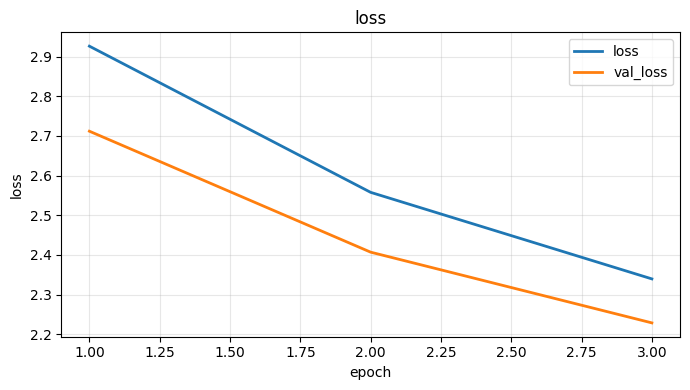

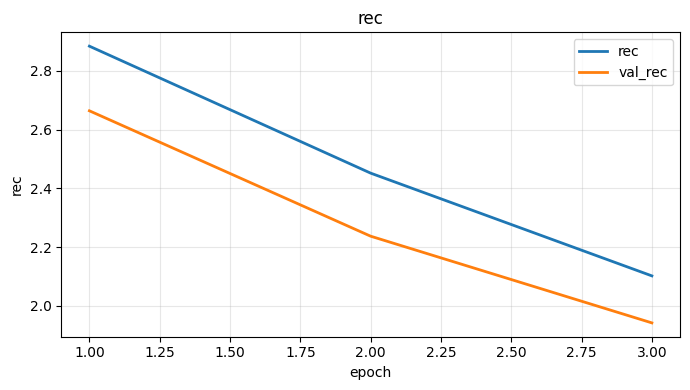

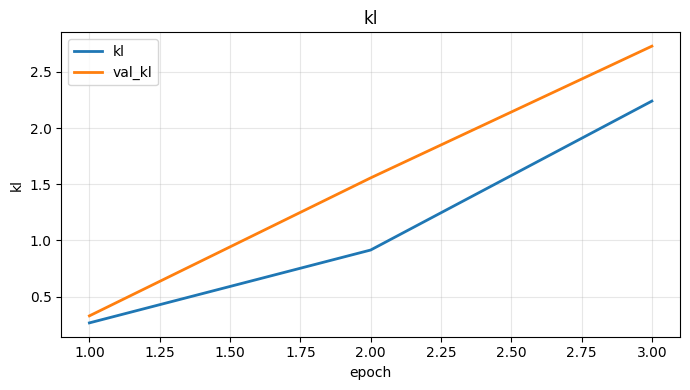

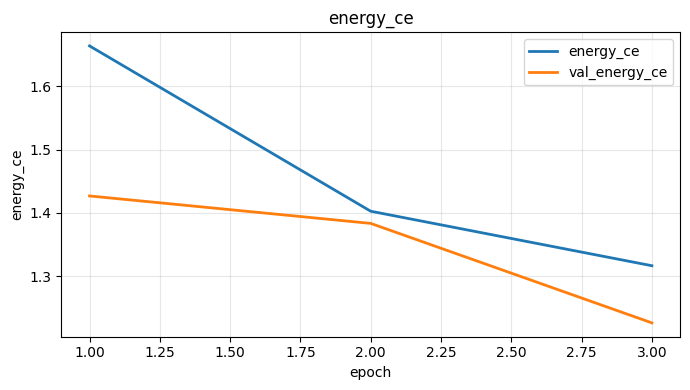

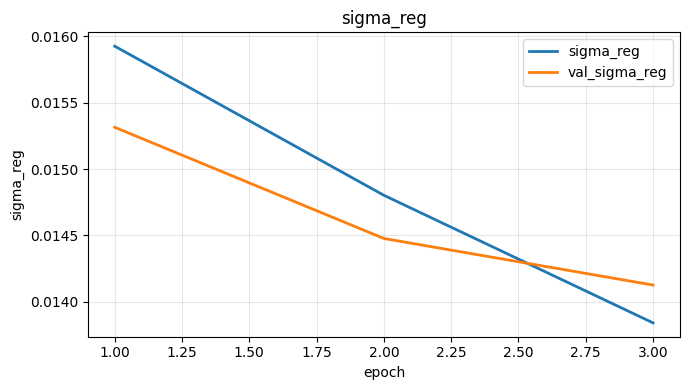

In [8]:
magi.plot_history(history)

## 7. Save the trained run`save_final_trained_model` writes weights + config + metadata + history + ahuman-readable summary as one unit under `save_dir`. Always keep this set of filestogether — generation needs both the weights *and* the preprocessing metadata (energybins, quantile transformers via `geometry_metadata`, `idx_to_type`, ...) to reconstructphysical quantities correctly.

In [9]:
model_config = {
    "model_class": "CVAE_CatEnergy_ContPhi_TaskAdaptive",
    "n_types": n_types,
    "n_energy_bins": n_energy_bins,
    "y_cont_dim": Y_CONT_DIM,
    "latent_dim": 4,
    "hidden": [16, 16],
    "beta": 0.1,
}

preprocessing_metadata = {
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "cont_cols": dataset_pack["cont_cols"],
    "y_cont_dim": Y_CONT_DIM,
    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,
    "geometry_metadata": geometry_metadata,
}

save_info = magi.save_final_trained_model(
    model=model,
    save_dir="trained_models/example_run",
    model_name="example_cvae",
    history=history,
    model_config=model_config,
    preprocessing_metadata=preprocessing_metadata,
    notes="Toy example run on synthetic data - not representative of real training.",
)
save_info

Saved final trained model to: trained_models/example_run


{'weights_path': 'trained_models/example_run/example_cvae.weights.h5',
 'config_path': 'trained_models/example_run/example_cvae_config.json',
 'metadata_path': 'trained_models/example_run/example_cvae_metadata.json',
 'history_path': 'trained_models/example_run/example_cvae_history.json',
 'task_weights_path': 'trained_models/example_run/example_cvae_task_weights.json',
 'summary_path': 'trained_models/example_run/example_cvae_summary.txt'}

## 8. Generate and reconstructSample latent codes conditioned on particle type, decode, then invert the geometrytransform (`reconstruct_generated_features`) and map back to physical `x,y,z,vx,vy,vz`(`reconstruct_generated_physics`). We also reconstruct the held-out real test set thesame way, for a like-for-like comparison in the next step.

In [10]:
NGEN = len(X_cont_test)

gen_raw = magi.generate_latent_outputs(
    model=model, n_samples=NGEN, type_probs=type_probs, n_types=n_types, idx_to_type=idx_to_type,
)
gen_feat = magi.reconstruct_generated_features(
    gen_raw,
    energy_bins=energy_bins,
    energy_mode="uniform",
    qt_u_r=qt_u_r, qt_u_v=qt_u_v, qt_phi_r=qt_phi_r, qt_phi_v=qt_phi_v,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)
gen_phys = magi.reconstruct_generated_physics(gen_feat, center=center, radius=R)

real_phys = magi.reconstruct_real_test_physics(
    X_cont_test=X_cont_test,
    E_test_raw=E_test_raw,
    qt_u_r=qt_u_r, qt_u_v=qt_u_v, qt_phi_r=qt_phi_r, qt_phi_v=qt_phi_v,
    center=center, radius=R,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)

print("Generated:", len(gen_phys["E_gen"]), "  Real test set:", len(real_phys["E_real"]))

Generated: 600   Real test set: 600


## 9. Validate`compute_wasserstein_scores` gives a single distance per physical variable between realand generated distributions — the main "did training work" signal (alongside`compare_hist_with_residuals` for a visual per-bin residual check). With only 3 toyepochs these will look mediocre; that's expected and not the point of this notebook.

In [11]:
scores = magi.compute_wasserstein_scores(real_phys, gen_phys)
scores

{'logE': 0.04578947393356851,
 'u_r': 0.02398400075453578,
 'u_v': 0.03910933143761282,
 'x': 0.4558291106978595,
 'y': 0.4795992001582682,
 'z': 0.47968001509071545,
 'cphi_r': 0.02485229031118727,
 'sphi_r': 0.03466398834518064,
 'cphi_v': 0.29735411730668465,
 'sphi_v': 0.03576140379288125,
 'vx': 0.2336224413471138,
 'vy': 0.02831550511248051,
 'vz': 0.039109331437521086,
 'phi_r': 0.1654962469241793,
 'phi_v': 0.39386205958796217,
 'u_r_q': 0.049129351133015024,
 'u_v_q': 0.07269884885133557,
 'phi_r_q': 0.11712129442411731,
 'phi_v_q': 0.2601367425516946}

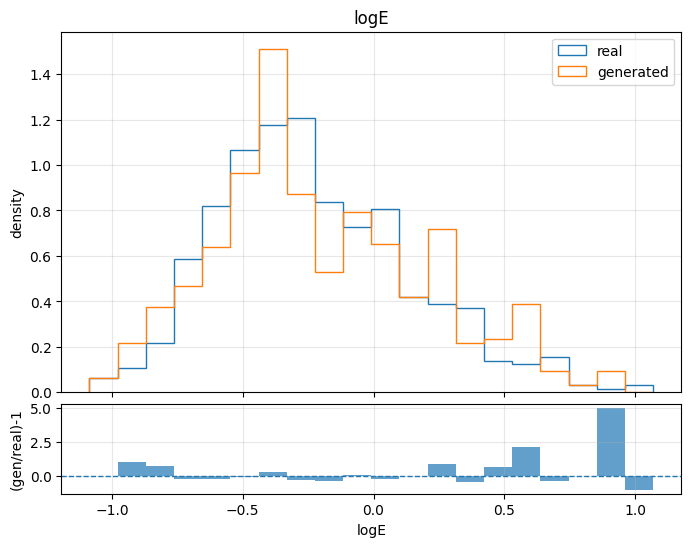

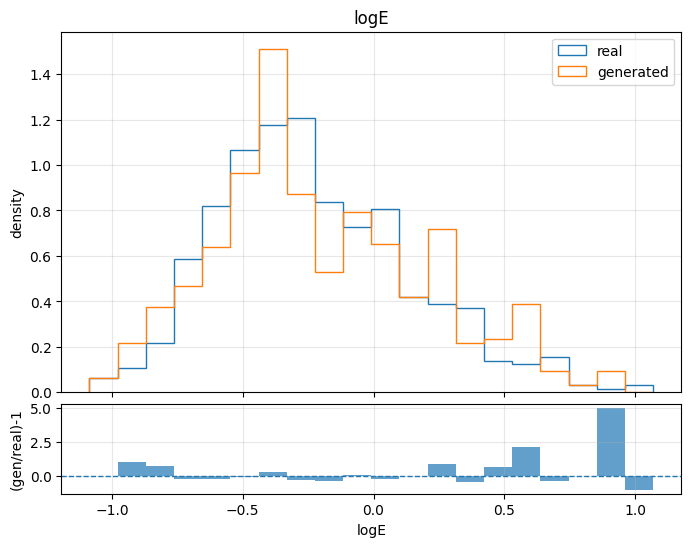

In [12]:
magi.compare_hist_with_residuals(
    real_phys["logE_real"], gen_phys["logE_gen"], name="logE", bins=20,
)

## 10. Export a Geant4-ready particle file`generate_detector_table_to_file` samples directly to disk in chunks — this is whatproduces the actual particle-source file a Geant4 macro loads(`/generator/generatedFile ...`), and what[`scripts/generate_geant_source.py`](scripts/generate_geant_source.py) wraps for directinvocation from a macro (`/generator/mlScript ...`). `geometry_metadata` needs the fittedquantile transformers merged in, exactly as it would be read back from saved metadata ina real run.

In [13]:
export_geometry_metadata = dict(geometry_metadata)
export_geometry_metadata.update(quantile_transformers)

magi.generate_detector_table_to_file(
    model=model,
    filepath="example_generated_particles.txt",
    n_events=200,
    type_probs=type_probs,
    n_types=n_types,
    idx_to_type=idx_to_type,
    energy_bins=energy_bins,
    geometry_metadata=export_geometry_metadata,
    center=center,
    radius=R,
    seed=123,
    output_format="text",
    verbose=1,
)

# Sanity check: load it back. generate_detector_table_to_file writes the plain
# "ParticleName Energy X Y Z Vx Vy Vz" 8-column format (no EventId/PrimBool -
# that's the Geant4 *input* convention, distinct from the raw crossing-data
# schemas load_detector_table auto-detects), so pass columns explicitly.
generated_check = magi.load_detector_table(
    "example_generated_particles.txt",
    columns=["ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"],
    drop_event_id=False,
)
generated_check.head()

[MAGI] Generating chunk attempted=0 written=0 / target=200


[MAGI] Saved generated detector text file to example_generated_particles.txt
[MAGI] Raw generated samples attempted: 200
[MAGI] Transport particles written: 200


/Volumes/X10Pro/MAGI/MAGI_package/magi/data/io.py:104: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support sep=None with delim_whitespace=False; you can avoid this warning by specifying engine='python'.
  df = pd.read_table(


,ParticleName,Energy,X,Y,Z,Vx,Vy,Vz
0,e-,1.893000,8.562535,-4.371386,-67.537787,0.449635,0.555059,0.699813
1,gamma,0.299046,6.263694,9.428064,-33.511284,0.823751,0.468814,0.318823
2,gamma,0.722868,-2.117568,15.998647,-38.186483,0.757326,0.588598,0.282861
3,gamma,0.357939,-10.588600,8.435510,-35.278461,0.303637,0.739029,0.601366
4,gamma,2.851141,-5.457722,14.050897,-63.144792,-0.137475,0.981208,-0.135395


## Next steps

- Full usage guide and current limitations (sphere-only geometry, the
  `geometry_transform` contract, `prob_threshold`, energy-binning modes, quantile-fit
  sample-size sensitivity, `source_type` correctness): [`MAGI_package/docs/USAGE.md`](MAGI_package/docs/USAGE.md).
- A real training run on real data with the full callback stack: `MAGI_v0_7_2.ipynb` at
  the repo root.
- The v0.8 mixture-energy head — candidate-line table, gate targets, flow continuum,
  learned prior, and the line-recovery validation that goes with them:
  `MAGI_v0_8_1.ipynb`. `magi.print_model_structure(model)` prints a description of any
  built model, including the mixture formulas and the configured line table.
- To swap in your own data: everything above works identically on a real
  `load_detector_table(...)` output — just point `filepath` at your actual Geant4
  crossing-data file, pick `center`/`radius` to match your detector surface, and pick
  `source_type` to match how your source is generated (see step 1's aside).